2 pictures were found
the total number of contours: 126
کانتور #16: مساحت=20538, نسبت=2.50, extent=0.46)
کانتور #28: مساحت=22867, نسبت=1.74, extent=0.48)
کانتور #39: مساحت=16180, نسبت=1.67, extent=0.51)
کانتور #64: مساحت=38153, نسبت=1.14, extent=0.42)
کانتور #70: مساحت=28114, نسبت=0.87, extent=0.41)
کانتور #91: مساحت=10667, نسبت=1.89, extent=0.55)
کانتور #120: مساحت=51978, نسبت=1.78, extent=0.31)
کانتورهای معتبر: 7
the total number of contours: 948
کانتور #43: مساحت=1014, نسبت=2.07, extent=0.15)
کانتور #101: مساحت=586, نسبت=2.40, extent=0.27)
کانتور #132: مساحت=704, نسبت=1.25, extent=0.14)
کانتور #211: مساحت=931, نسبت=1.85, extent=0.17)
کانتور #235: مساحت=2540, نسبت=0.96, extent=0.17)
کانتور #330: مساحت=574, نسبت=1.46, extent=0.23)
کانتور #363: مساحت=1388, نسبت=0.76, extent=0.19)
کانتور #364: مساحت=679, نسبت=1.09, extent=0.32)
کانتور #365: مساحت=620, نسبت=0.84, extent=0.36)
کانتور #417: مساحت=644, نسبت=0.76, extent=0.12)
کانتور #425: مساحت=2156, نسبت=3.16, extent=0.17)
کانتور #437: مسا

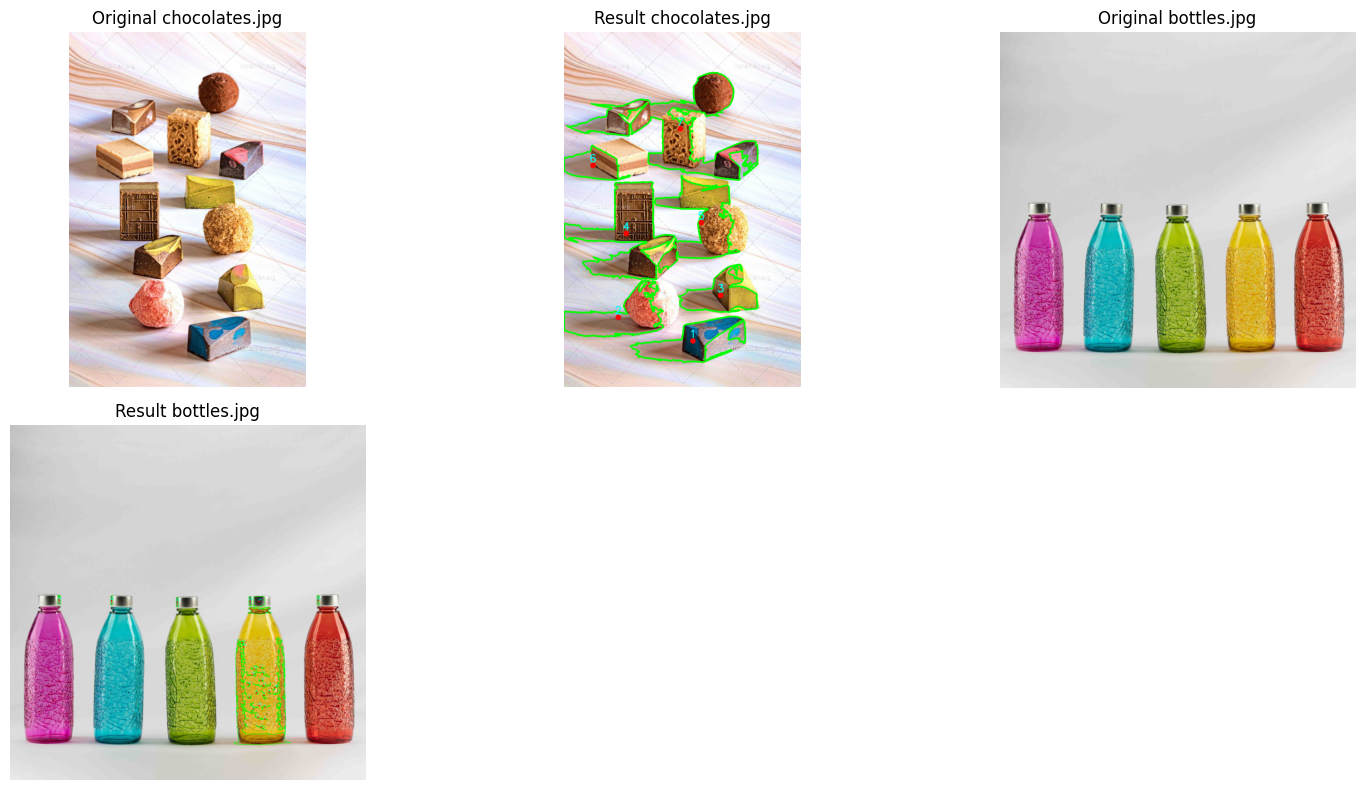

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files
from IPython.display import display
import ipywidgets as widgets
import os

def show_grid(images, titles, rows=2, cols=3, cmaps=None, size=(15, 8)):
    """نمایش تصاویر در grid با عناوین"""
    plt.figure(figsize=size)
    if cmaps is None:
        cmaps = [None] * len(images)

    for i, (img, title, cmap) in enumerate(zip(images, titles, cmaps), 1):
        plt.subplot(rows, cols, i)
        if cmap == 'gray':
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def count_objects_pipelines(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU) # Fixed cv2.thresh
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) # Fixed cv2.RETR_EXRENAL and variable name

    print(f"the total number of contours: {len(contours)}")

    result = img.copy()
    filtered_contours = []
    for i, cnt in enumerate(contours):
        area = cv2.contourArea(cnt)
        if 500 < area < 400000:
            x, y, w, h = cv2.boundingRect(cnt)
            ratio = w / float(h)
            rect_area = w * h
            extent = area / rect_area
            print(f"کانتور #{i}: مساحت={area:.0f}, نسبت={ratio:.2f}, extent={extent:.2f})") # Fixed: added closing double quote and parenthesis
            filtered_contours.append(cnt)

    print(f"کانتورهای معتبر: {len(filtered_contours)}")
    cv2.drawContours(result, filtered_contours, -1, (0, 255, 0), 4)


    for i, cnt in enumerate(filtered_contours):
        M = cv2.moments(cnt)
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])

            cv2.circle(result, (cx, cy), 8, (0, 0, 255), -1)
            cv2.putText(result, str(i + 1), (cx - 10, cy - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)
    return result


folder_path = '/content/'
image_files = [f for f in os.listdir(".") if f.lower().endswith(".jpg")]
print(f"{len(image_files)} pictures were found")

images = []
titles = []
for f in image_files:
    image_path = os.path.join(folder_path, f)
    img = cv2.imread(image_path)
    if img is None: # Fixed 'f' to 'img'
        print(f"Failed to load image: {f}")
        continue

    result = count_objects_pipelines(img)
    images.append(img)
    titles.append(f"Original {f}")
    images.append(result)
    titles.append(f"Result {f}")


if images:
    show_grid(images, titles, rows=2, cols=3, cmaps=None, size=(15, 8))

2 pictures were found
the total number of contours: 126
کانتورهای معتبر: 6
the total number of contours: 948
کانتورهای معتبر: 4


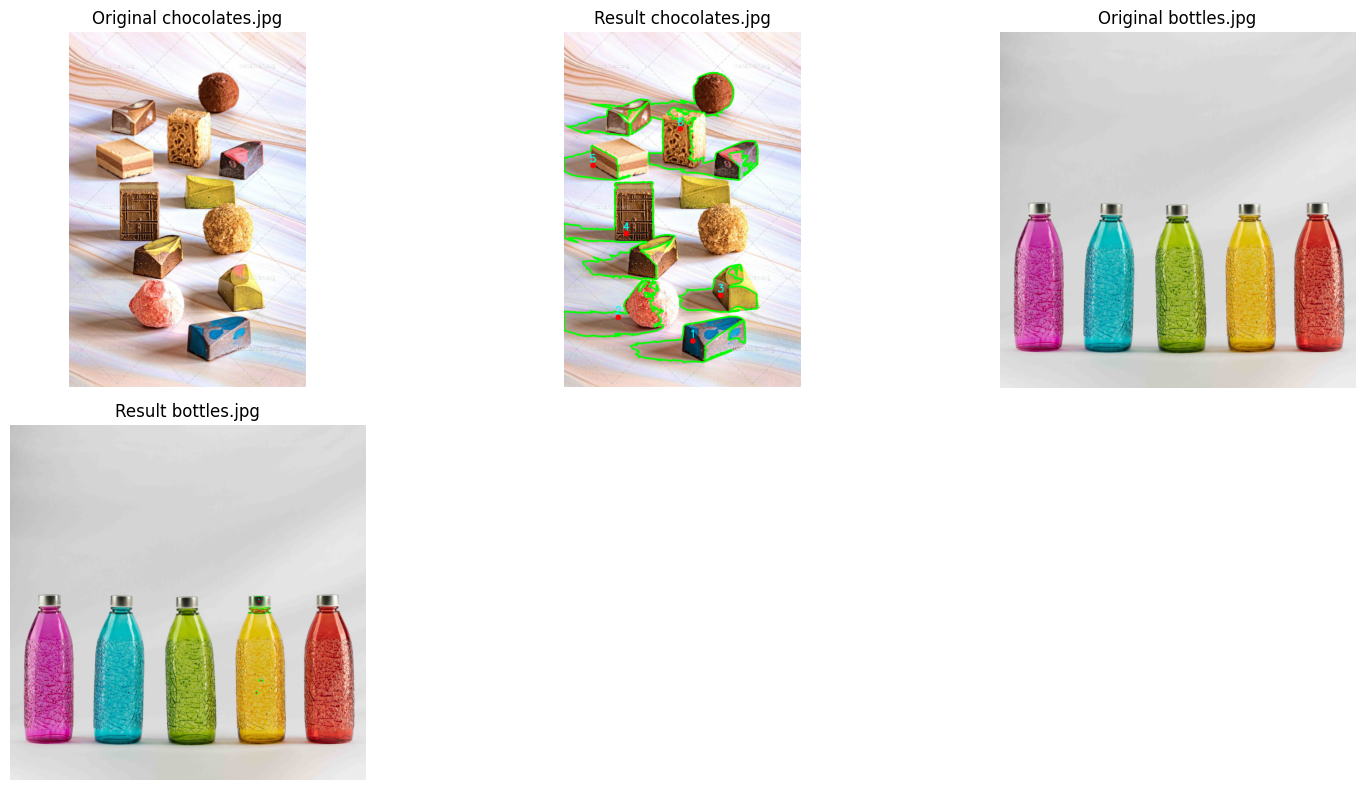

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files
from IPython.display import display
import ipywidgets as widgets
import os

def show_grid(images, titles, rows=2, cols=3, cmaps=None, size=(15, 8)):
    """نمایش تصاویر در grid با عناوین"""
    plt.figure(figsize=size)
    if cmaps is None:
        cmaps = [None] * len(images)

    for i, (img, title, cmap) in enumerate(zip(images, titles, cmaps), 1):
        plt.subplot(rows, cols, i)
        if cmap == 'gray':
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def count_objects_pipelines(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU) # Fixed cv2.thresh
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) # Fixed cv2.RETR_EXRENAL and variable name

    print(f"the total number of contours: {len(contours)}")

    result = img.copy()
    filtered_contours = []
    for i, cnt in enumerate(contours):
        area = cv2.contourArea(cnt)
        if 500 < area < 400000:
            x, y, w, h = cv2.boundingRect(cnt)
            ratio = w / float(h)
            rect_area = w * h
            extent = area / rect_area
            if 0.9 <= ratio <=3.7 and extent > 0.3:
                filtered_contours.append(cnt) # Corrected indentation

    print(f"کانتورهای معتبر: {len(filtered_contours)}")
    cv2.drawContours(result, filtered_contours, -1, (0, 255, 0), 4)


    for i, cnt in enumerate(filtered_contours):
        M = cv2.moments(cnt)
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])

            cv2.circle(result, (cx, cy), 8, (0, 0, 255), -1)
            cv2.putText(result, str(i + 1), (cx - 10, cy - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)
    return result


folder_path = '/content/'
image_files = [f for f in os.listdir(".") if f.lower().endswith(".jpg")]
print(f"{len(image_files)} pictures were found")

images = []
titles = []
for f in image_files:
    image_path = os.path.join(folder_path, f)
    img = cv2.imread(image_path)
    if img is None: # Fixed 'f' to 'img'
        print(f"Failed to load image: {f}")
        continue

    result = count_objects_pipelines(img)
    images.append(img)
    titles.append(f"Original {f}")
    images.append(result)
    titles.append(f"Result {f}")


if images:
    show_grid(images, titles, rows=2, cols=3, cmaps=None, size=(15, 8))


2 pictures were found
the total number of contours: 1125
کانتور #214: مساحت=7170, نسبت=1.37, extent=0.31)
کانتور #406: مساحت=6186, نسبت=1.72, extent=0.19)
کانتور #430: مساحت=1141, نسبت=7.71, extent=0.26)
کانتور #444: مساحت=5565, نسبت=2.61, extent=0.20)
کانتور #455: مساحت=1086, نسبت=0.50, extent=0.18)
کانتور #646: مساحت=4579, نسبت=1.31, extent=0.15)
کانتور #679: مساحت=4778, نسبت=1.82, extent=0.08)
کانتور #692: مساحت=3376, نسبت=0.94, extent=0.25)
کانتور #721: مساحت=1135, نسبت=3.96, extent=0.14)
کانتور #788: مساحت=2384, نسبت=0.90, extent=0.35)
کانتور #807: مساحت=3304, نسبت=1.10, extent=0.24)
کانتور #863: مساحت=1225, نسبت=2.68, extent=0.32)
کانتور #927: مساحت=1812, نسبت=1.75, extent=0.17)
کانتور #934: مساحت=3272, نسبت=1.03, extent=0.09)
کانتور #997: مساحت=11774, نسبت=1.67, extent=0.42)
کانتورهای معتبر: 15
the total number of contours: 7990
کانتور #26: مساحت=2218, نسبت=13.11, extent=0.47)
کانتور #61: مساحت=3603, نسبت=10.54, extent=0.20)
کانتور #75: مساحت=4060, نسبت=11.97, extent=0.26)
کانتو

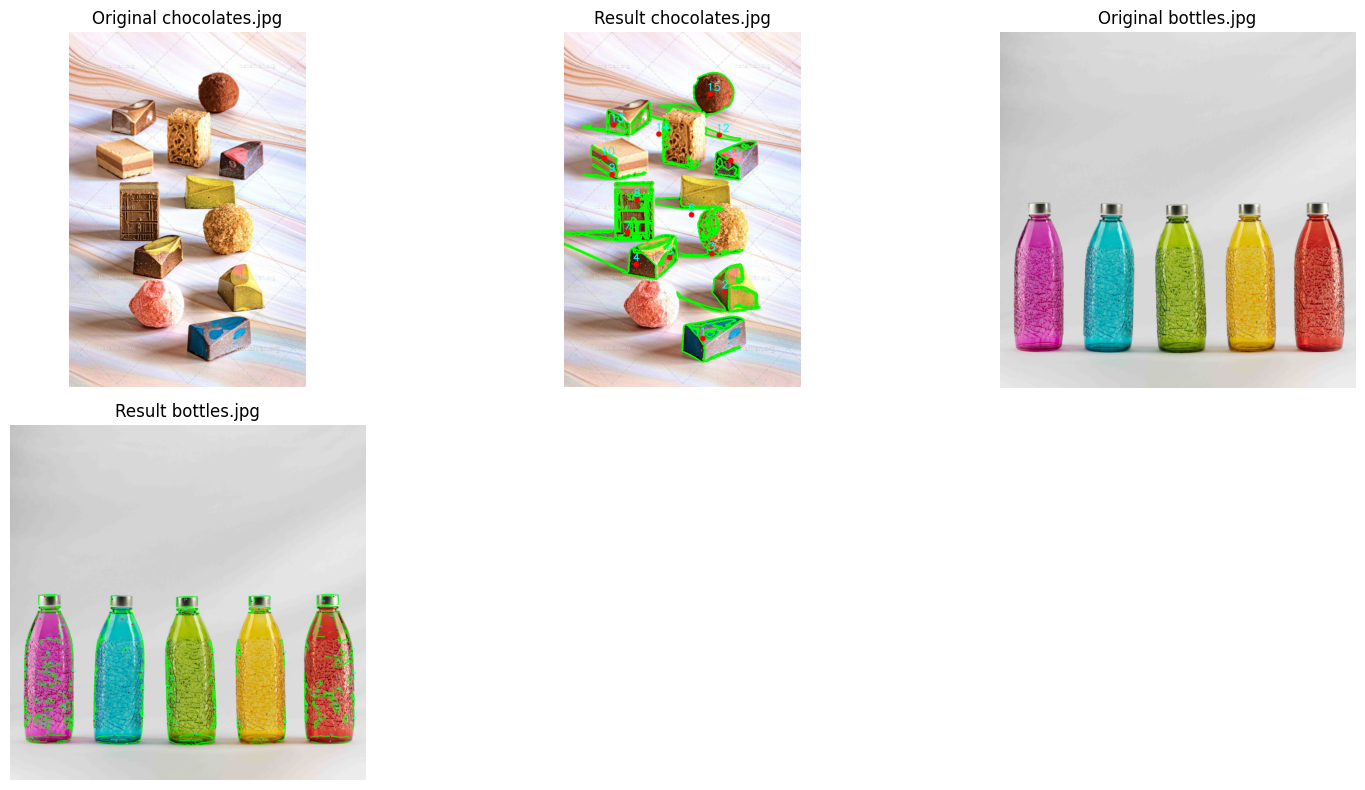

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files
from IPython.display import display
import ipywidgets as widgets
import os

def show_grid(images, titles, rows=2, cols=3, cmaps=None, size=(15, 8)):
    """نمایش تصاویر در grid با عناوین"""
    plt.figure(figsize=size)
    if cmaps is None:
        cmaps = [None] * len(images)

    for i, (img, title, cmap) in enumerate(zip(images, titles, cmaps), 1):
        plt.subplot(rows, cols, i)
        if cmap == 'gray':
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def count_objects_pipelines(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    thresh = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 21, 10)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) # Fixed cv2.RETR_EXRENAL and variable name

    print(f"the total number of contours: {len(contours)}")

    result = img.copy()
    filtered_contours = []
    for i, cnt in enumerate(contours):
        area = cv2.contourArea(cnt)
        if 1000 < area < 400000:
            x, y, w, h = cv2.boundingRect(cnt)
            ratio = w / float(h)
            rect_area = w * h
            extent = area / rect_area
            print(f"کانتور #{i}: مساحت={area:.0f}, نسبت={ratio:.2f}, extent={extent:.2f})") # Fixed: added closing double quote and parenthesis
            filtered_contours.append(cnt)

    print(f"کانتورهای معتبر: {len(filtered_contours)}")
    cv2.drawContours(result, filtered_contours, -1, (0, 255, 0), 4)


    for i, cnt in enumerate(filtered_contours):
        M = cv2.moments(cnt)
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])

            cv2.circle(result, (cx, cy), 8, (0, 0, 255), -1)
            cv2.putText(result, str(i + 1), (cx - 10, cy - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)
    return result


folder_path = '/content/'
image_files = [f for f in os.listdir(".") if f.lower().endswith(".jpg")]
print(f"{len(image_files)} pictures were found")

images = []
titles = []
for f in image_files:
    image_path = os.path.join(folder_path, f)
    img = cv2.imread(image_path)
    if img is None: # Fixed 'f' to 'img'
        print(f"Failed to load image: {f}")
        continue

    result = count_objects_pipelines(img)
    images.append(img)
    titles.append(f"Original {f}")
    images.append(result)
    titles.append(f"Result {f}")


if images:
    show_grid(images, titles, rows=2, cols=3, cmaps=None, size=(15, 8))